#  TASK 3:- CUSTOMER DEMOGRAPHIC ANALYSIS (PYTHON)

### Tech Stack :- Python , Pandas , Matplotlib

### Description :- Load a CSV file containing customer demographic and travel-related data. Perform Exploratory Data Analysis (EDA) using Python, Pandas, and Matplotlib to understand customer behavior. Analyze the most popular travel destinations, group customers by age and income bracket, and study spending patterns. Generate basic visualizations such as bar charts and histograms to present the findings clearly and effectively. This analysis helps in identifying customer segments and understanding demographic trends in travel preferences.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load the CSV File

In [2]:
df = pd.read_csv('CUSTOMER DEMOGRAPHIC ANAIYSIS.dataset.csv')
df

,Age,Gender,Income_Level,Preferred_Travel_Type,Avg_Trip_Duration,Spending_Amount,Booking_Channel,Repeat_Visitor,Customer_Review_Score,Cluster_Label
0,56,Female,Low,Cultural,9,1149.85,Website,No,1.2,0
1,69,Male,Low,Leisure,12,1770.33,Website,No,4.4,0
2,46,Male,Low,Leisure,8,3946.28,Website,Yes,4.8,0
3,32,Female,Medium,Leisure,20,1040.96,Agent,No,3.8,0
4,60,Other,High,Adventure,11,3227.87,Agent,Yes,2.5,2
...,...,...,...,...,...,...,...,...,...,...
2451,38,Male,Low,Leisure,6,4242.15,Agent,Yes,2.1,2
2452,30,Male,High,Cultural,5,1555.03,Website,Yes,4.0,2
2453,39,Female,Medium,Adventure,3,3978.29,Agent,No,3.1,2
2454,36,Female,Medium,Cultural,11,587.51,Agent,Yes,1.3,1


In [3]:
df.head()

,Age,Gender,Income_Level,Preferred_Travel_Type,Avg_Trip_Duration,Spending_Amount,Booking_Channel,Repeat_Visitor,Customer_Review_Score,Cluster_Label
0,56,Female,Low,Cultural,9,1149.85,Website,No,1.2,0
1,69,Male,Low,Leisure,12,1770.33,Website,No,4.4,0
2,46,Male,Low,Leisure,8,3946.28,Website,Yes,4.8,0
3,32,Female,Medium,Leisure,20,1040.96,Agent,No,3.8,0
4,60,Other,High,Adventure,11,3227.87,Agent,Yes,2.5,2


In [4]:
df.tail()

,Age,Gender,Income_Level,Preferred_Travel_Type,Avg_Trip_Duration,Spending_Amount,Booking_Channel,Repeat_Visitor,Customer_Review_Score,Cluster_Label
2451,38,Male,Low,Leisure,6,4242.15,Agent,Yes,2.1,2
2452,30,Male,High,Cultural,5,1555.03,Website,Yes,4.0,2
2453,39,Female,Medium,Adventure,3,3978.29,Agent,No,3.1,2
2454,36,Female,Medium,Cultural,11,587.51,Agent,Yes,1.3,1
2455,51,Male,Medium,Religious,6,4131.54,Website,Yes,2.5,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2456 entries, 0 to 2455
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    2456 non-null   int64  
 1   Gender                 2456 non-null   object 
 2   Income_Level           2456 non-null   object 
 3   Preferred_Travel_Type  2456 non-null   object 
 4   Avg_Trip_Duration      2456 non-null   int64  
 5   Spending_Amount        2456 non-null   float64
 6   Booking_Channel        2456 non-null   object 
 7   Repeat_Visitor         2456 non-null   object 
 8   Customer_Review_Score  2456 non-null   float64
 9   Cluster_Label          2456 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 192.0+ KB


In [6]:
df.columns

Index(['Age', 'Gender', 'Income_Level', 'Preferred_Travel_Type',
       'Avg_Trip_Duration', 'Spending_Amount', 'Booking_Channel',
       'Repeat_Visitor', 'Customer_Review_Score', 'Cluster_Label'],
      dtype='object')

In [7]:
df.describe()

,Age,Avg_Trip_Duration,Spending_Amount,Customer_Review_Score,Cluster_Label
count,2456.000000,2456.000000,2456.000000,2456.000000,2456.000000
mean,43.724756,11.150244,2537.616726,3.023697,1.517915
std,14.948846,5.483973,1403.183329,1.145550,1.127550
min,18.000000,2.000000,100.910000,1.000000,0.000000
25%,31.000000,6.000000,1356.252500,2.100000,0.000000
50%,44.000000,11.000000,2533.520000,3.100000,2.000000
75%,56.000000,16.000000,3723.617500,4.000000,3.000000
max,69.000000,20.000000,4998.210000,5.000000,3.000000


## Check for Missing Values

In [8]:
df.isnull().sum()

Age                      0
Gender                   0
Income_Level             0
Preferred_Travel_Type    0
Avg_Trip_Duration        0
Spending_Amount          0
Booking_Channel          0
Repeat_Visitor           0
Customer_Review_Score    0
Cluster_Label            0
dtype: int64

## Find Most Popular Travel Destination

In [9]:
travel_type_count = df["Preferred_Travel_Type"].value_counts()
print(travel_type_count)

Preferred_Travel_Type
Leisure      648
Adventure    619
Cultural     599
Religious    590
Name: count, dtype: int64


## Create Age Groups

In [10]:
bins = [0, 25, 35, 50, 100]
labels = ["Below 25", "26-35", "36-50", "Above 50"]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

print(df[["Age", "AgeGroup"]].head())

   Age  AgeGroup
0   56  Above 50
1   69  Above 50
2   46     36-50
3   32     26-35
4   60  Above 50


## Count Customers in Each Age Group 

In [11]:
age_group_count = df['AgeGroup'].value_counts()
print(age_group_count)

AgeGroup
Above 50    905
36-50       726
26-35       451
Below 25    374
Name: count, dtype: int64


## Analyze Income Level

In [14]:
income_count = df['Income_Level'].value_counts() 
print(income_count)

Income_Level
Medium    1228
Low        741
High       487
Name: count, dtype: int64


## Find Average Trip Duration by Income Level

In [19]:
Avg_Trip_Duration  = df.groupby('Income_Level')['Avg_Trip_Duration'].mean() 
print(Avg_Trip_Duration)

Income_Level
High      11.342916
Low       11.219973
Medium    11.031759
Name: Avg_Trip_Duration, dtype: float64


## Draw Bar Chart for Age Groups

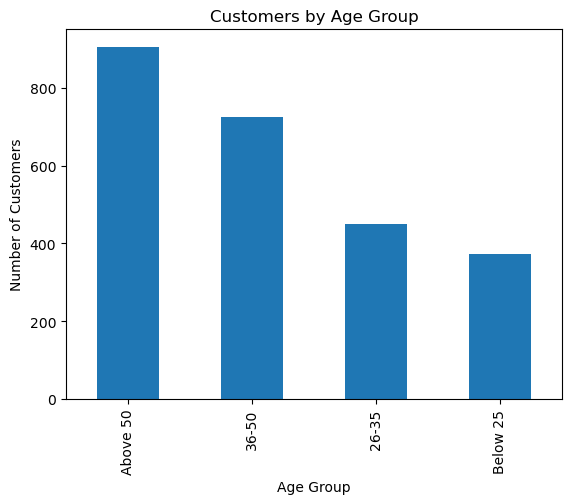

In [20]:
age_group_count.plot(kind='bar') 
plt.title('Customers by Age Group') 
plt.xlabel('Age Group') 
plt.ylabel('Number of Customers')
plt.show()

## Create Histogram of Age Distribution

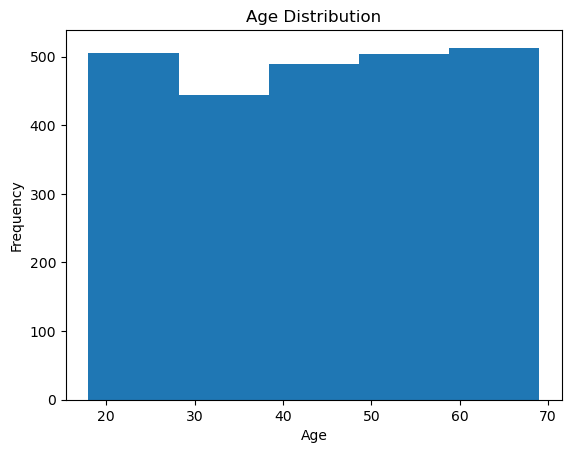

In [21]:
plt.hist(df['Age'], bins=5) 
plt.title('Age Distribution') 
plt.xlabel('Age') 
plt.ylabel('Frequency') 
plt.show()

## Income Level (Pie Chart)

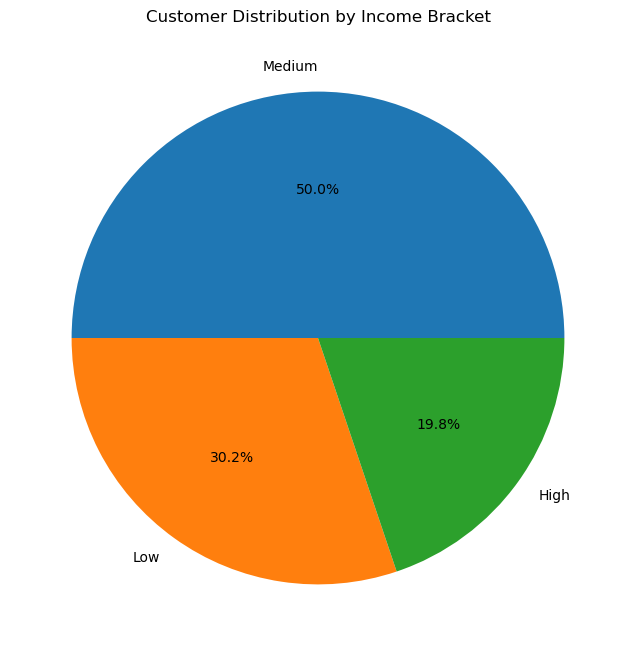

In [23]:
income_count = df['Income_Level'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(income_count.values,labels=income_count.index,autopct='%1.1f%%')
plt.title('Customer Distribution by Income Bracket')
plt.show()

## Age vs Spending Amount (Scatter Plot)

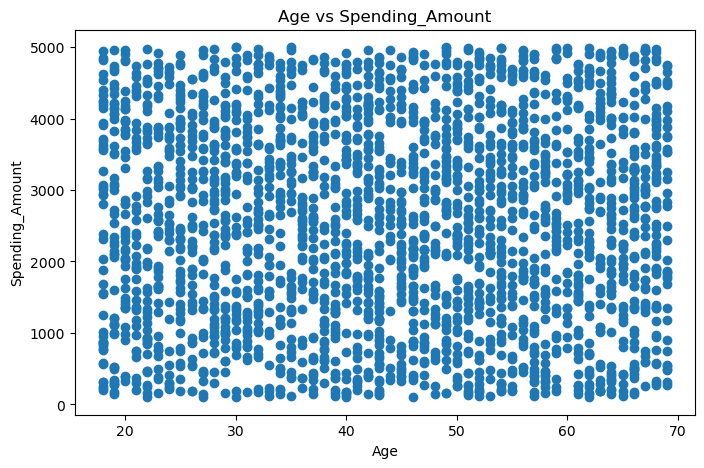

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Age'], df['Spending_Amount'])
plt.title('Age vs Spending_Amount')
plt.xlabel('Age')
plt.ylabel('Spending_Amount')
plt.show()

## Draw Bar Chart for Income Brackets

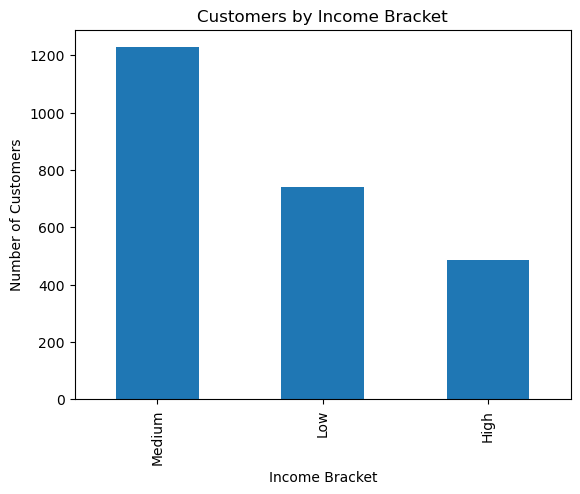

In [27]:
income_count.plot(kind='bar')
plt.title('Customers by Income Bracket')
plt.xlabel('Income Bracket')
plt.ylabel('Number of Customers') 
plt.show()